# Multi-Virus Respiratory Infection Comparison

**Research Question:** How do SARS-CoV-2, Influenza A, and RSV differ in their gene expression responses?

**Dataset:** GSE147507 (RNA-seq, human airway cells, 24hr infection)

**Analysis:** Differential expression for each virus, comparative visualization, identification of shared vs unique gene signatures.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Statistical analysis
from scipy import stats
from scipy.cluster import hierarchy
from statsmodels.stats.multitest import multipletests

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Create directories
os.makedirs('./figures', exist_ok=True)
os.makedirs('./results', exist_ok=True)

print("✅ All libraries loaded successfully!")
print(f"📁 Working directory: {os.getcwd()}")

✅ All libraries loaded successfully!
📁 Working directory: C:\Users\damilola\PycharmProjects\Bioinformatics_Portfolio\Multi-Virus Comparisons


# Load Data from Previous Project

In [4]:
# Load the expression data (already downloaded from previous project)
print("📂 Loading expression data...")

# Check if data exists
data_path = './data/raw_counts.tsv'

if not os.path.exists(data_path):
    print("❌ Data file not found!")
    print("💡 Make sure you have the data from your previous DE analysis project")
    print("   Expected location: ./data/raw_counts.tsv")
else:
    # Load data
    expr_df = pd.read_csv(data_path, sep='\t', index_col=0)

    print(f"✅ Data loaded successfully!")
    print(f"   Genes: {expr_df.shape[0]}")
    print(f"   Samples: {expr_df.shape[1]}")

    # Show first few sample names to see the pattern
    print(f"\n📋 First 10 sample names:")
    for i, sample in enumerate(expr_df.columns[:10], 1):
        print(f"   {i}. {sample}")

    print(f"\n💡 Total samples: {expr_df.shape[1]}")

📂 Loading expression data...
✅ Data loaded successfully!
   Genes: 21797
   Samples: 78

📋 First 10 sample names:
   1. Series1_NHBE_Mock_1
   2. Series1_NHBE_Mock_2
   3. Series1_NHBE_Mock_3
   4. Series1_NHBE_SARS-CoV-2_1
   5. Series1_NHBE_SARS-CoV-2_2
   6. Series1_NHBE_SARS-CoV-2_3
   7. Series2_A549_Mock_1
   8. Series2_A549_Mock_2
   9. Series2_A549_Mock_3
   10. Series2_A549_SARS-CoV-2_1

💡 Total samples: 78


# Organize all samples by type

In [6]:
# Categorize all samples by virus type
print("🔬 Organizing samples by virus type...\n")

sample_groups = {
    'Mock': [],
    'SARS-CoV-2': [],
    'IAV': [],
    'RSV': [],
    'Other': []
}

# Go through each sample and categorize it
for sample in expr_df.columns:
    if 'Mock' in sample:
        sample_groups['Mock'].append(sample)
    elif 'SARS-CoV-2' in sample:
        sample_groups['SARS-CoV-2'].append(sample)
    elif 'IAV' in sample:
        sample_groups['IAV'].append(sample)
    elif 'RSV' in sample:
        sample_groups['RSV'].append(sample)
    else:
        sample_groups['Other'].append(sample)

# Display the results
print("📊 Sample counts by virus:")
for virus, samples in sample_groups.items():
    print(f"   {virus}: {len(samples)} samples")

# Show some examples
print("\n📋 Sample examples:")
print(f"   Mock (first 3): {sample_groups['Mock'][:3]}")
print(f"   SARS-CoV-2 (first 3): {sample_groups['SARS-CoV-2'][:3]}")
print(f"   IAV (first 3): {sample_groups['IAV'][:3]}")
print(f"   RSV (first 3): {sample_groups['RSV'][:3]}")

# Check if we found all three viruses
if len(sample_groups['IAV']) > 0 and len(sample_groups['RSV']) > 0:
    print("\n✅ Perfect! Found all three viruses for comparison!")
else:
    print("\n⚠️ Some viruses missing - let's check the data")

🔬 Organizing samples by virus type...

📊 Sample counts by virus:
   Mock: 29 samples
   SARS-CoV-2: 21 samples
   IAV: 10 samples
   RSV: 5 samples
   Other: 13 samples

📋 Sample examples:
   Mock (first 3): ['Series1_NHBE_Mock_1', 'Series1_NHBE_Mock_2', 'Series1_NHBE_Mock_3']
   SARS-CoV-2 (first 3): ['Series1_NHBE_SARS-CoV-2_1', 'Series1_NHBE_SARS-CoV-2_2', 'Series1_NHBE_SARS-CoV-2_3']
   IAV (first 3): ['Series4_A549_IAV_1', 'Series4_A549_IAV_2', 'Series9_NHBE_IAV_1']
   RSV (first 3): ['Series3_A549_RSV_1', 'Series3_A549_RSV_2', 'Series8_A549_RSV_1']

✅ Perfect! Found all three viruses for comparison!


# Quality Control and Filtering

In [7]:
# Quality Control: Filter low-expressed genes
print("🧹 Quality Control & Filtering...\n")

# Original gene count
print(f"Starting genes: {expr_df.shape[0]:,}")

# Filter: Keep genes with >10 counts in at least 3 samples
# (Standard cutoff to remove noise)
expr_filtered = expr_df[(expr_df > 10).sum(axis=1) >= 3]

print(f"After filtering: {expr_filtered.shape[0]:,} genes")
print(f"Removed: {expr_df.shape[0] - expr_filtered.shape[0]:,} low-expressed genes\n")

# Log2 transformation (for statistical analysis)
expr_log2 = np.log2(expr_filtered + 1)  # +1 to avoid log(0)

print("✅ Data ready for analysis!")
print(f"   Final matrix: {expr_log2.shape[0]:,} genes × {expr_log2.shape[1]} samples")

🧹 Quality Control & Filtering...

Starting genes: 21,797
After filtering: 15,427 genes
Removed: 6,370 low-expressed genes

✅ Data ready for analysis!
   Final matrix: 15,427 genes × 78 samples


# Visualizing QC plot

📊 Creating QC visualizations...

✅ QC plots saved: ./figures/qc_plots.png


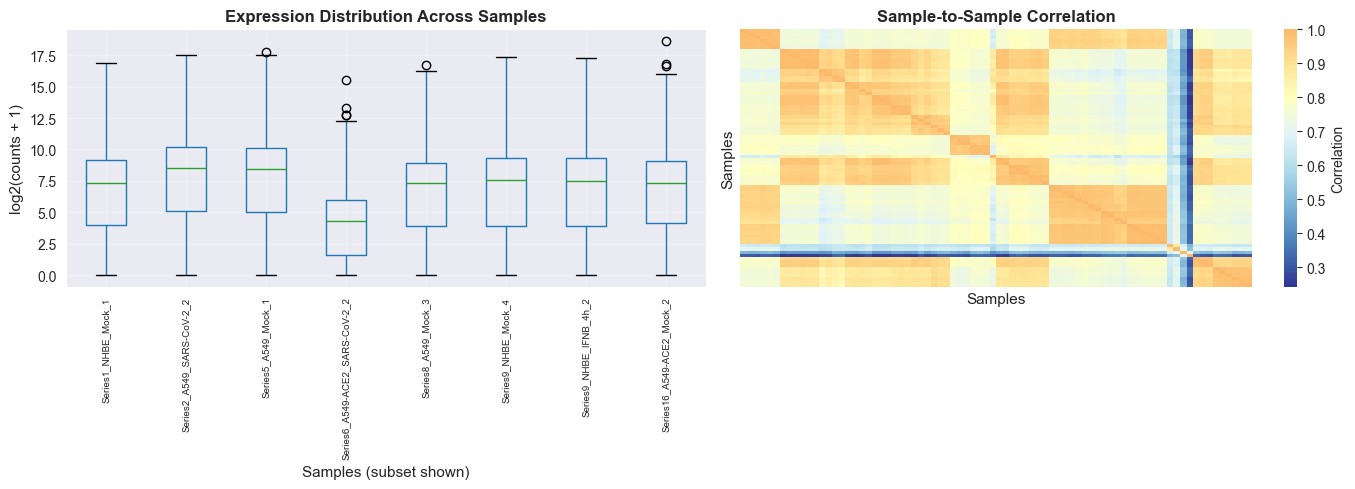

In [8]:
# Quality Control Plots
print("📊 Creating QC visualizations...\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of expression values (Boxplot)
# Shows if samples are comparable
sample_subset = expr_log2.iloc[:, ::10]  # Every 10th sample (to avoid clutter)
sample_subset.boxplot(ax=axes[0], rot=90)
axes[0].set_title('Expression Distribution Across Samples', fontsize=12, fontweight='bold')
axes[0].set_ylabel('log2(counts + 1)', fontsize=11)
axes[0].set_xlabel('Samples (subset shown)', fontsize=11)
axes[0].tick_params(axis='x', labelsize=7)
axes[0].grid(True, alpha=0.3)

# Plot 2: Sample correlation heatmap
# Shows if samples cluster by virus type
corr_matrix = expr_log2.corr()
sns.heatmap(corr_matrix, cmap='RdYlBu_r', center=0.8,
            cbar_kws={'label': 'Correlation'}, ax=axes[1],
            xticklabels=False, yticklabels=False)  # Hide labels (too many!)
axes[1].set_title('Sample-to-Sample Correlation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Samples', fontsize=11)
axes[1].set_ylabel('Samples', fontsize=11)

plt.tight_layout()
plt.savefig('./figures/qc_plots.png', dpi=300, bbox_inches='tight')
print("✅ QC plots saved: ./figures/qc_plots.png")
plt.show()

# Differential Expression Analysis [SARS-CoV-2 vs Mock]

In [9]:
# Differential Expression Analysis #1: SARS-CoV-2 vs Mock
print("="*60)
print("DIFFERENTIAL EXPRESSION ANALYSIS: SARS-CoV-2 vs Mock")
print("="*60 + "\n")

# Get sample lists
covid_samples = sample_groups['SARS-CoV-2']
mock_samples = sample_groups['Mock']

print(f"Comparing:")
print(f"  - SARS-CoV-2: {len(covid_samples)} samples")
print(f"  - Mock: {len(mock_samples)} samples\n")

# Extract expression data for these groups
covid_expr = expr_filtered[covid_samples]
mock_expr = expr_filtered[mock_samples]

# Calculate statistics for each gene
covid_results = []

for gene in expr_filtered.index:
    covid_vals = covid_expr.loc[gene].values
    mock_vals = mock_expr.loc[gene].values

    # Calculate means with pseudocount
    mean_covid = np.mean(covid_vals) + 1
    mean_mock = np.mean(mock_vals) + 1

    # Fold change
    fold_change = mean_covid / mean_mock
    log2fc = np.log2(fold_change)

    # T-test
    t_stat, p_value = stats.ttest_ind(covid_vals, mock_vals)

    covid_results.append({
        'Gene': gene,
        'Mean_COVID': mean_covid,
        'Mean_Mock': mean_mock,
        'Log2FC': log2fc,
        'P_value': p_value
    })

# Create DataFrame
covid_de = pd.DataFrame(covid_results)

# Remove inf/nan
covid_de = covid_de.replace([np.inf, -np.inf], np.nan).dropna()

# FDR correction
covid_de['Adjusted_P'] = multipletests(covid_de['P_value'], method='fdr_bh')[1]
covid_de['-log10(p)'] = -np.log10(covid_de['Adjusted_P'])

# Classify genes
covid_de['Regulation'] = 'Not Significant'
covid_de.loc[(covid_de['Log2FC'] > 1) & (covid_de['Adjusted_P'] < 0.05), 'Regulation'] = 'Up'
covid_de.loc[(covid_de['Log2FC'] < -1) & (covid_de['Adjusted_P'] < 0.05), 'Regulation'] = 'Down'

# Summary
print("✅ SARS-CoV-2 Analysis Complete!")
print(f"\nResults:")
print(f"  - Upregulated: {sum(covid_de['Regulation'] == 'Up')} genes")
print(f"  - Downregulated: {sum(covid_de['Regulation'] == 'Down')} genes")
print(f"  - Not significant: {sum(covid_de['Regulation'] == 'Not Significant')} genes")

# Save
covid_de.to_csv('./results/covid_de_results.csv', index=False)
print(f"\n💾 Saved: ./results/covid_de_results.csv")

DIFFERENTIAL EXPRESSION ANALYSIS: SARS-CoV-2 vs Mock

Comparing:
  - SARS-CoV-2: 21 samples
  - Mock: 29 samples

✅ SARS-CoV-2 Analysis Complete!

Results:
  - Upregulated: 125 genes
  - Downregulated: 0 genes
  - Not significant: 15294 genes

💾 Saved: ./results/covid_de_results.csv


# Differential Expression Analysis [IAV vs Mock]

In [10]:
# Differential Expression Analysis #2: IAV vs Mock
print("="*60)
print("DIFFERENTIAL EXPRESSION ANALYSIS: Influenza (IAV) vs Mock")
print("="*60 + "\n")

iav_samples = sample_groups['IAV']
print(f"Comparing:")
print(f"  - IAV: {len(iav_samples)} samples")
print(f"  - Mock: {len(mock_samples)} samples\n")

iav_expr = expr_filtered[iav_samples]
iav_results = []

for gene in expr_filtered.index:
    iav_vals = iav_expr.loc[gene].values
    mock_vals = mock_expr.loc[gene].values

    mean_iav = np.mean(iav_vals) + 1
    mean_mock = np.mean(mock_vals) + 1
    fold_change = mean_iav / mean_mock
    log2fc = np.log2(fold_change)
    t_stat, p_value = stats.ttest_ind(iav_vals, mock_vals)

    iav_results.append({
        'Gene': gene,
        'Mean_IAV': mean_iav,
        'Mean_Mock': mean_mock,
        'Log2FC': log2fc,
        'P_value': p_value
    })

iav_de = pd.DataFrame(iav_results)
iav_de = iav_de.replace([np.inf, -np.inf], np.nan).dropna()
iav_de['Adjusted_P'] = multipletests(iav_de['P_value'], method='fdr_bh')[1]
iav_de['-log10(p)'] = -np.log10(iav_de['Adjusted_P'])
iav_de['Regulation'] = 'Not Significant'
iav_de.loc[(iav_de['Log2FC'] > 1) & (iav_de['Adjusted_P'] < 0.05), 'Regulation'] = 'Up'
iav_de.loc[(iav_de['Log2FC'] < -1) & (iav_de['Adjusted_P'] < 0.05), 'Regulation'] = 'Down'

print("✅ IAV Analysis Complete!")
print(f"\nResults:")
print(f"  - Upregulated: {sum(iav_de['Regulation'] == 'Up')} genes")
print(f"  - Downregulated: {sum(iav_de['Regulation'] == 'Down')} genes")

iav_de.to_csv('./results/iav_de_results.csv', index=False)
print(f"\n💾 Saved: ./results/iav_de_results.csv")

DIFFERENTIAL EXPRESSION ANALYSIS: Influenza (IAV) vs Mock

Comparing:
  - IAV: 10 samples
  - Mock: 29 samples

✅ IAV Analysis Complete!

Results:
  - Upregulated: 289 genes
  - Downregulated: 5 genes

💾 Saved: ./results/iav_de_results.csv


# Differential Expression Analysis [RSV vs Mock]

In [11]:
# Differential Expression Analysis #3: RSV vs Mock
print("="*60)
print("DIFFERENTIAL EXPRESSION ANALYSIS: RSV vs Mock")
print("="*60 + "\n")

rsv_samples = sample_groups['RSV']
print(f"Comparing:")
print(f"  - RSV: {len(rsv_samples)} samples")
print(f"  - Mock: {len(mock_samples)} samples\n")

rsv_expr = expr_filtered[rsv_samples]
rsv_results = []

for gene in expr_filtered.index:
    rsv_vals = rsv_expr.loc[gene].values
    mock_vals = mock_expr.loc[gene].values

    mean_rsv = np.mean(rsv_vals) + 1
    mean_mock = np.mean(mock_vals) + 1
    fold_change = mean_rsv / mean_mock
    log2fc = np.log2(fold_change)
    t_stat, p_value = stats.ttest_ind(rsv_vals, mock_vals)

    rsv_results.append({
        'Gene': gene,
        'Mean_RSV': mean_rsv,
        'Mean_Mock': mean_mock,
        'Log2FC': log2fc,
        'P_value': p_value
    })

rsv_de = pd.DataFrame(rsv_results)
rsv_de = rsv_de.replace([np.inf, -np.inf], np.nan).dropna()
rsv_de['Adjusted_P'] = multipletests(rsv_de['P_value'], method='fdr_bh')[1]
rsv_de['-log10(p)'] = -np.log10(rsv_de['Adjusted_P'])
rsv_de['Regulation'] = 'Not Significant'
rsv_de.loc[(rsv_de['Log2FC'] > 1) & (rsv_de['Adjusted_P'] < 0.05), 'Regulation'] = 'Up'
rsv_de.loc[(rsv_de['Log2FC'] < -1) & (rsv_de['Adjusted_P'] < 0.05), 'Regulation'] = 'Down'

print("✅ RSV Analysis Complete!")
print(f"\nResults:")
print(f"  - Upregulated: {sum(rsv_de['Regulation'] == 'Up')} genes")
print(f"  - Downregulated: {sum(rsv_de['Regulation'] == 'Down')} genes")

rsv_de.to_csv('./results/rsv_de_results.csv', index=False)
print(f"\n💾 Saved: ./results/rsv_de_results.csv")

DIFFERENTIAL EXPRESSION ANALYSIS: RSV vs Mock

Comparing:
  - RSV: 5 samples
  - Mock: 29 samples

✅ RSV Analysis Complete!

Results:
  - Upregulated: 121 genes
  - Downregulated: 0 genes

💾 Saved: ./results/rsv_de_results.csv


# Extract DEG Genes

In [12]:
# Extract lists of significantly DEGs for each virus
print("="*60)
print("EXTRACTING DIFFERENTIALLY EXPRESSED GENE LISTS")
print("="*60 + "\n")

covid_degs = set(covid_de[covid_de['Regulation'] != 'Not Significant']['Gene'])
iav_degs = set(iav_de[iav_de['Regulation'] != 'Not Significant']['Gene'])
rsv_degs = set(rsv_de[rsv_de['Regulation'] != 'Not Significant']['Gene'])

print(f"DEG counts:")
print(f"  - SARS-CoV-2: {len(covid_degs)} genes")
print(f"  - IAV: {len(iav_degs)} genes")
print(f"  - RSV: {len(rsv_degs)} genes")

# Find overlaps
all_three = covid_degs & iav_degs & rsv_degs
covid_iav = (covid_degs & iav_degs) - rsv_degs
covid_rsv = (covid_degs & rsv_degs) - iav_degs
iav_rsv = (iav_degs & rsv_degs) - covid_degs
covid_only = covid_degs - iav_degs - rsv_degs
iav_only = iav_degs - covid_degs - rsv_degs
rsv_only = rsv_degs - covid_degs - iav_degs

print(f"\nOverlaps:")
print(f"  - All 3 viruses: {len(all_three)} genes")
print(f"  - COVID + IAV only: {len(covid_iav)} genes")
print(f"  - COVID + RSV only: {len(covid_rsv)} genes")
print(f"  - IAV + RSV only: {len(iav_rsv)} genes")
print(f"  - COVID unique: {len(covid_only)} genes")
print(f"  - IAV unique: {len(iav_only)} genes")
print(f"  - RSV unique: {len(rsv_only)} genes")

EXTRACTING DIFFERENTIALLY EXPRESSED GENE LISTS

DEG counts:
  - SARS-CoV-2: 125 genes
  - IAV: 294 genes
  - RSV: 121 genes

Overlaps:
  - All 3 viruses: 3 genes
  - COVID + IAV only: 5 genes
  - COVID + RSV only: 8 genes
  - IAV + RSV only: 29 genes
  - COVID unique: 109 genes
  - IAV unique: 257 genes
  - RSV unique: 81 genes


# Venn Diagram


📊 Creating Venn diagram...

✅ Venn diagram saved: ./figures/venn_diagram.png


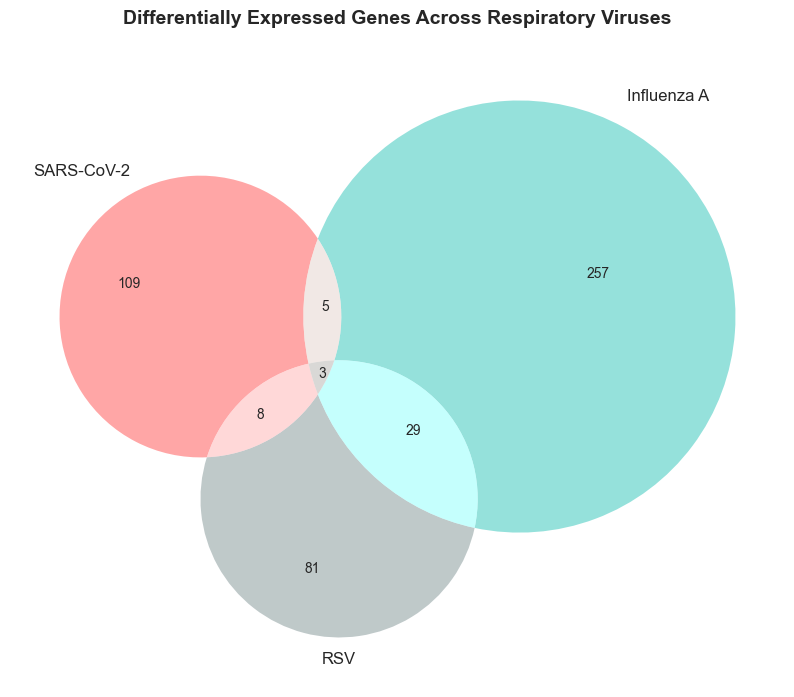

In [13]:
# Venn Diagram showing gene overlaps
print("\n📊 Creating Venn diagram...\n")

plt.figure(figsize=(10, 10))
venn3([covid_degs, iav_degs, rsv_degs],
      set_labels=('SARS-CoV-2', 'Influenza A', 'RSV'),
      set_colors=('#FF6B6B', '#4ECDC4', '#95A5A6'),
      alpha=0.6)

plt.title('Differentially Expressed Genes Across Respiratory Viruses',
          fontsize=14, fontweight='bold', pad=20)

plt.savefig('./figures/venn_diagram.png', dpi=300, bbox_inches='tight')
print("✅ Venn diagram saved: ./figures/venn_diagram.png")
plt.show()

# Clustered Heatmap


🔥 Creating clustered heatmap...



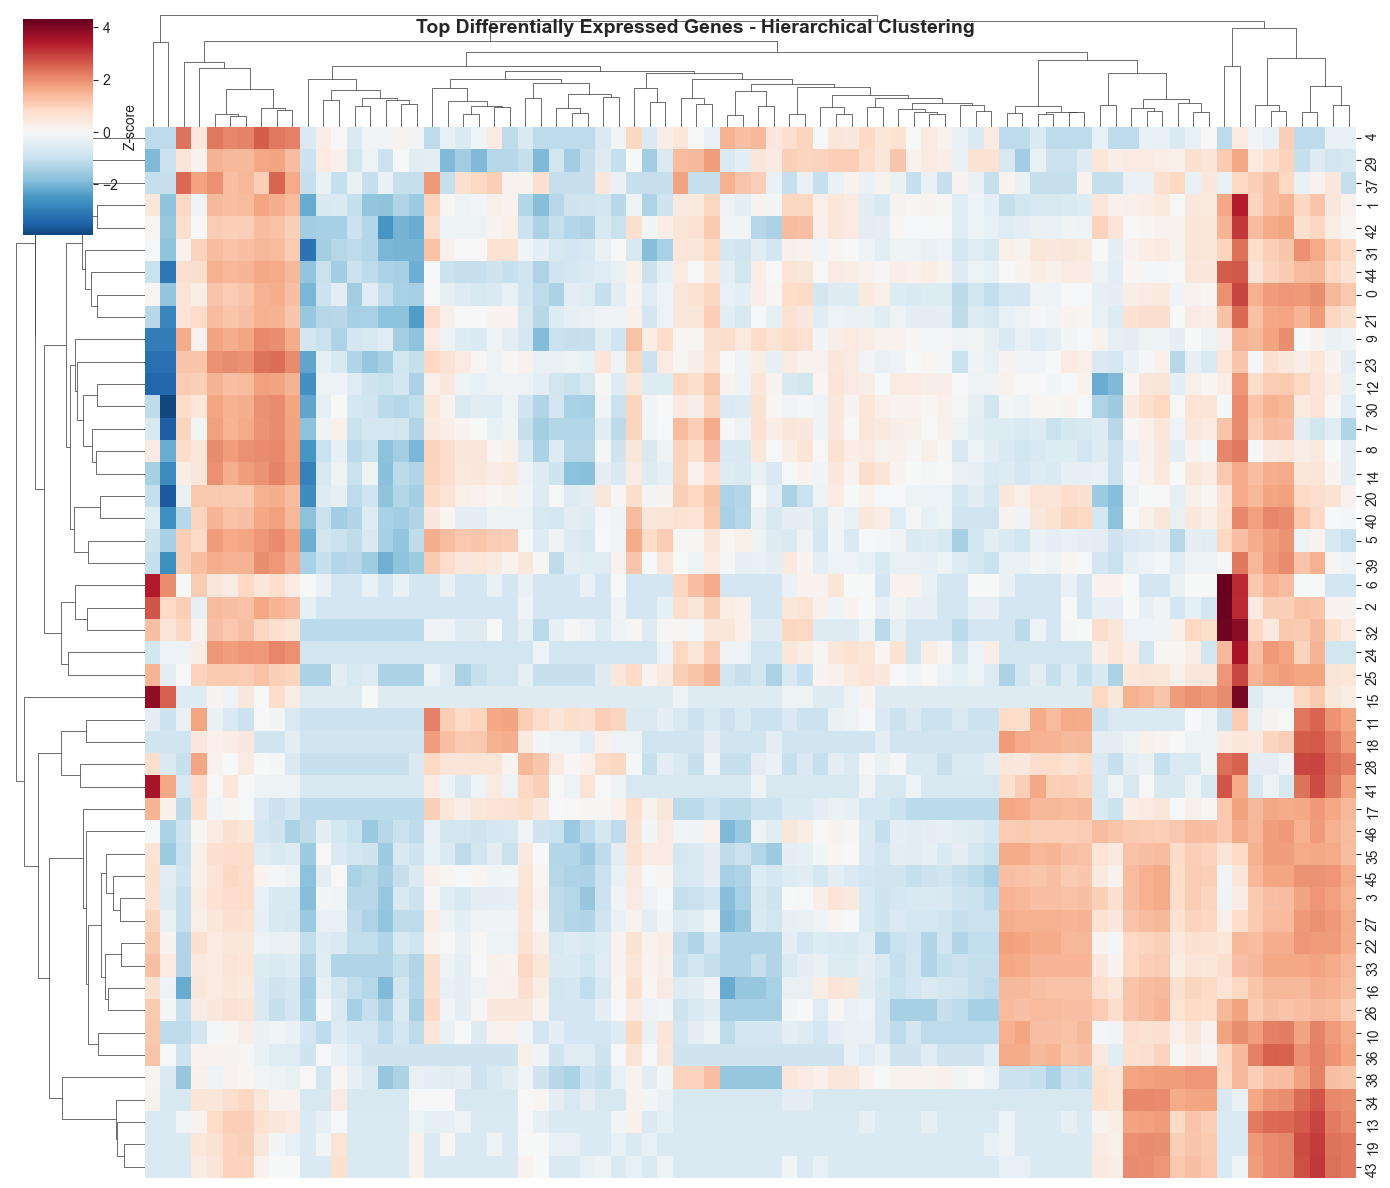

✅ Clustered heatmap saved successfully.


In [16]:
print("\n🔥 Creating clustered heatmap...\n")

# -----------------------------
# 1️⃣ Get top DEGs
# -----------------------------
covid_top = covid_de[covid_de['Regulation'] != 'Not Significant'] \
    .nlargest(25, 'Log2FC')['Gene']

iav_top = iav_de[iav_de['Regulation'] != 'Not Significant'] \
    .nlargest(15, 'Log2FC')['Gene']

rsv_top = rsv_de[rsv_de['Regulation'] != 'Not Significant'] \
    .nlargest(10, 'Log2FC')['Gene']

top_genes = list(set(list(covid_top) + list(iav_top) + list(rsv_top)))

# -----------------------------
# 2️⃣ Ensure gene index
# -----------------------------
if 'Gene' in expr_log2.columns:
    expr_log2 = expr_log2.set_index('Gene')

# Keep only genes that actually exist
top_genes = [g for g in top_genes if g in expr_log2.index]

# -----------------------------
# 3️⃣ Extract expression matrix
# -----------------------------
heatmap_data = expr_log2.loc[top_genes].copy()

# Force numeric
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')

# Remove genes with all NaN
heatmap_data = heatmap_data.dropna(how='all')

# Fill remaining NaN
heatmap_data = heatmap_data.fillna(0)

# -----------------------------
# 4️⃣ Remove zero-variance genes
# -----------------------------
heatmap_data = heatmap_data.loc[heatmap_data.std(axis=1) != 0]

# -----------------------------
# 5️⃣ Z-score normalize (row-wise)
# -----------------------------
from scipy.stats import zscore
import numpy as np

heatmap_data_norm = pd.DataFrame(
    zscore(heatmap_data, axis=1),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# Replace inf / NaN safely
heatmap_data_norm = np.nan_to_num(heatmap_data_norm)

# -----------------------------
# 6️⃣ Create clustered heatmap
# -----------------------------
sns.clustermap(
    heatmap_data_norm,
    cmap='RdBu_r',
    center=0,
    figsize=(14, 12),
    xticklabels=False,
    yticklabels=True,
    dendrogram_ratio=0.1,
    cbar_kws={'label': 'Z-score'}
)

plt.suptitle(
    'Top Differentially Expressed Genes - Hierarchical Clustering',
    fontsize=14,
    fontweight='bold'
)

plt.savefig('./figures/clustered_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Clustered heatmap saved successfully.")

# Comparative Volcano Plots


🌋 Creating comparative volcano plots...

✅ Comparative volcanoes saved: ./figures/comparative_volcanoes.png


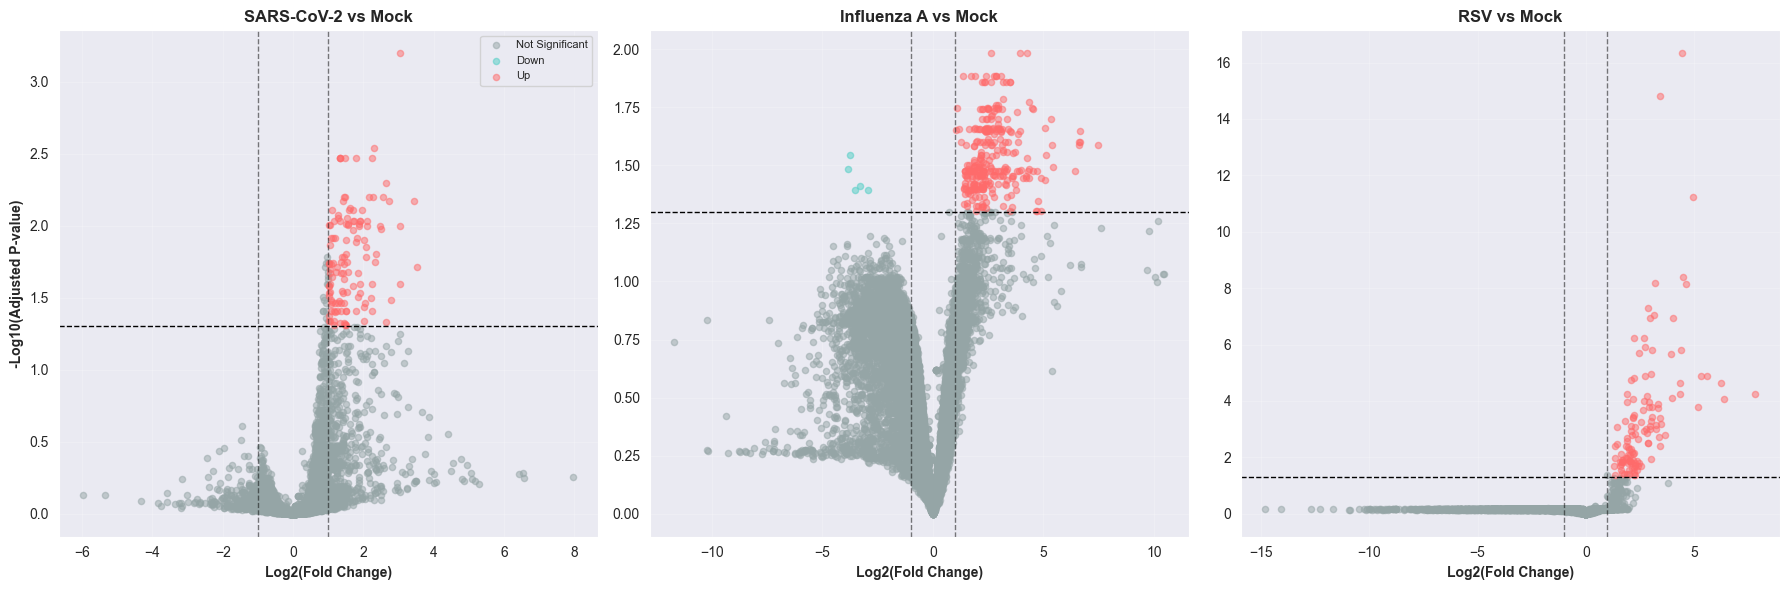

In [17]:
# Side-by-side volcano plots
print("\n🌋 Creating comparative volcano plots...\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {'Up': '#FF6B6B', 'Down': '#4ECDC4', 'Not Significant': '#95A5A6'}

# Plot 1: COVID
for regulation in ['Not Significant', 'Down', 'Up']:
    subset = covid_de[covid_de['Regulation'] == regulation]
    axes[0].scatter(subset['Log2FC'], subset['-log10(p)'],
                   c=colors[regulation], alpha=0.5, s=20, label=regulation)
axes[0].axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1)
axes[0].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axvline(x=-1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Log2(Fold Change)', fontweight='bold')
axes[0].set_ylabel('-Log10(Adjusted P-value)', fontweight='bold')
axes[0].set_title('SARS-CoV-2 vs Mock', fontweight='bold', fontsize=12)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.2)

# Plot 2: IAV
for regulation in ['Not Significant', 'Down', 'Up']:
    subset = iav_de[iav_de['Regulation'] == regulation]
    axes[1].scatter(subset['Log2FC'], subset['-log10(p)'],
                   c=colors[regulation], alpha=0.5, s=20)
axes[1].axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1)
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axvline(x=-1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Log2(Fold Change)', fontweight='bold')
axes[1].set_title('Influenza A vs Mock', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.2)

# Plot 3: RSV
for regulation in ['Not Significant', 'Down', 'Up']:
    subset = rsv_de[rsv_de['Regulation'] == regulation]
    axes[2].scatter(subset['Log2FC'], subset['-log10(p)'],
                   c=colors[regulation], alpha=0.5, s=20)
axes[2].axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1)
axes[2].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].axvline(x=-1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_xlabel('Log2(Fold Change)', fontweight='bold')
axes[2].set_title('RSV vs Mock', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('./figures/comparative_volcanoes.png', dpi=300, bbox_inches='tight')
print("✅ Comparative volcanoes saved: ./figures/comparative_volcanoes.png")
plt.show()

# Summary Bar Chart


📊 Creating summary bar chart...

✅ Bar chart saved: ./figures/deg_counts_comparison.png


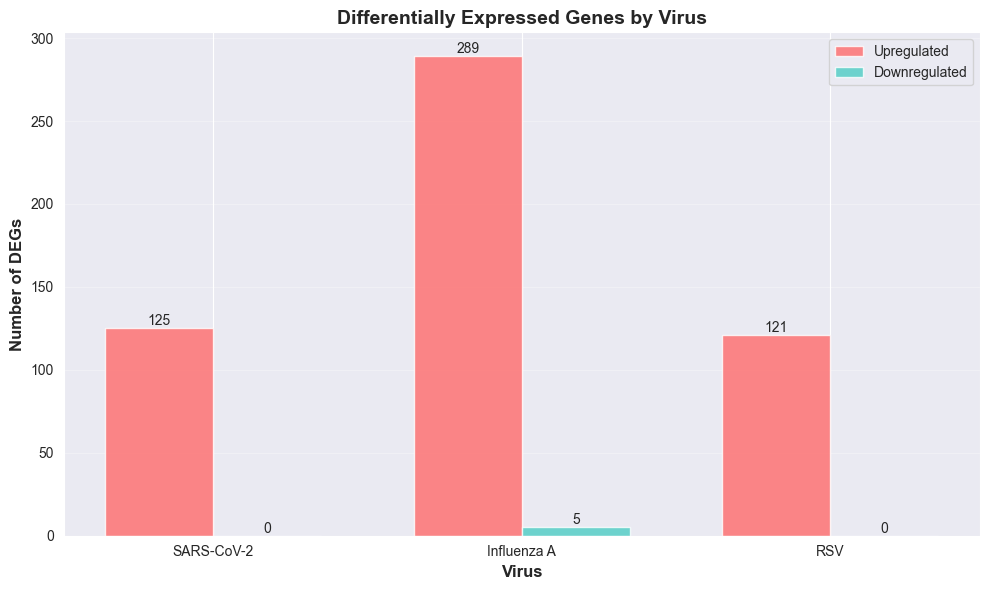

In [18]:
# Bar chart comparing DEG counts
print("\n📊 Creating summary bar chart...\n")

summary_data = {
    'Virus': ['SARS-CoV-2', 'Influenza A', 'RSV'],
    'Upregulated': [
        sum(covid_de['Regulation'] == 'Up'),
        sum(iav_de['Regulation'] == 'Up'),
        sum(rsv_de['Regulation'] == 'Up')
    ],
    'Downregulated': [
        sum(covid_de['Regulation'] == 'Down'),
        sum(iav_de['Regulation'] == 'Down'),
        sum(rsv_de['Regulation'] == 'Down')
    ]
}

summary_df = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary_df['Virus']))
width = 0.35

bars1 = ax.bar(x - width/2, summary_df['Upregulated'], width,
               label='Upregulated', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, summary_df['Downregulated'], width,
               label='Downregulated', color='#4ECDC4', alpha=0.8)

ax.set_xlabel('Virus', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of DEGs', fontweight='bold', fontsize=12)
ax.set_title('Differentially Expressed Genes by Virus', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Virus'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./figures/deg_counts_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Bar chart saved: ./figures/deg_counts_comparison.png")
plt.show()